In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

## Working with Perfectly Linear Dataset

In [25]:
from sklearn.datasets import make_blobs

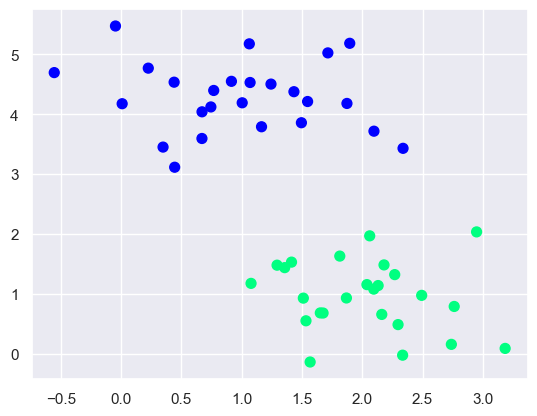

In [26]:
x,y = make_blobs(n_samples=50,centers=2,random_state=0,cluster_std=0.60)
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='winter')

In [27]:
from sklearn.svm import SVC  
model = SVC(kernel='linear',C=1)
model.fit(x,y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
def plot_svc_decision_function(model,ax=None,plot_support=True):
    """Plot The Decision Function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0],xlim[1],30)
    y = np.linspace(ylim[0],ylim[1],30)
    y,x = np.meshgrid(y,x)
    xy = np.vstack([x.ravel(),y.ravel()]).T
    p = model.decision_function(xy).reshape(x.shape)

    #plot decision boundary and margins
    ax.contour(x,y,p,colors='k',
               levels=[-1,0,1],alpha=0.5,linestyles=['--','-','--'])

    #plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:,0],model.support_vectors_[:,1],
                   s=300,linewidth=1,facecolors='none')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

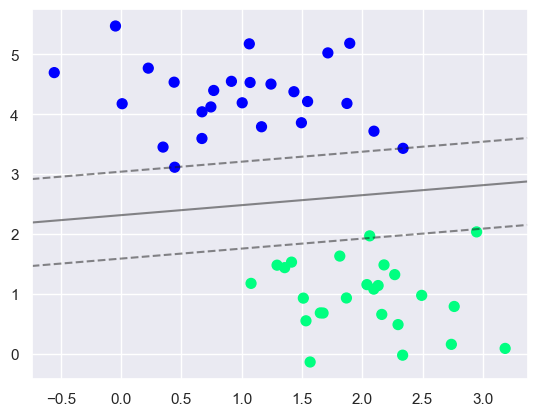

In [29]:
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='winter')
plot_svc_decision_function(model)

## Importance of Support Vector

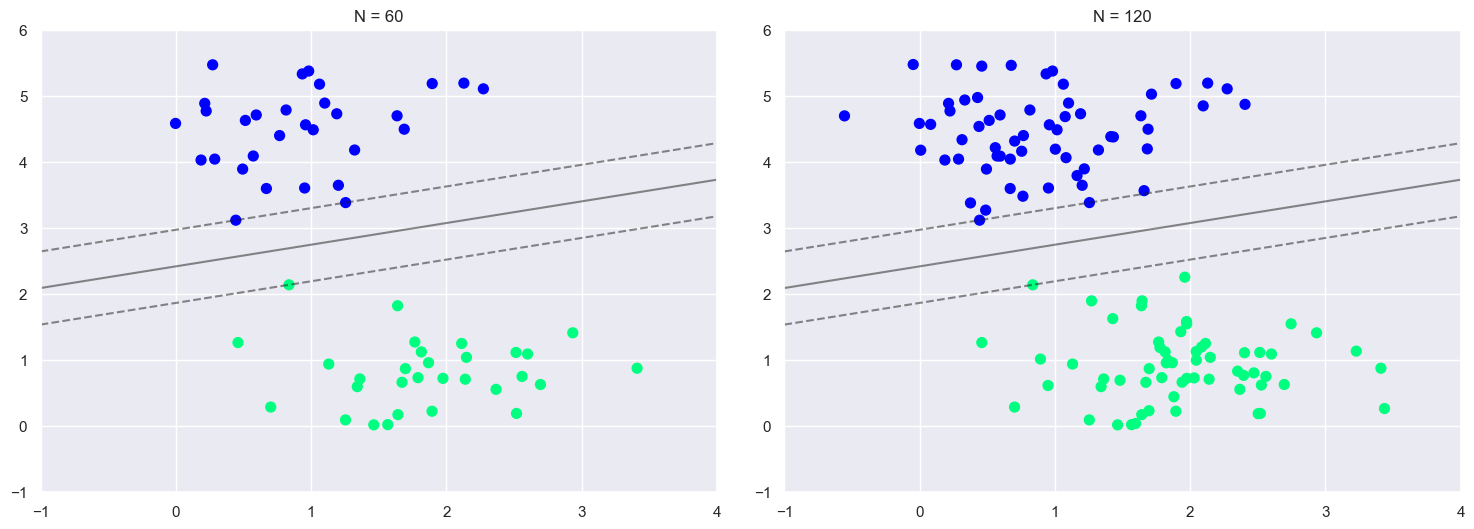

In [30]:
def plot_svm(N=10, ax=None):
    x, y = make_blobs(n_samples=200, centers=2,
                        random_state=0, cluster_std=0.60)
    x = x[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(x, y)
    
    ax = ax or plt.gca()
    ax.scatter(x[:, 0], x[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)
    
fig, ax =  plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

## Working with almost linearly separable datasets

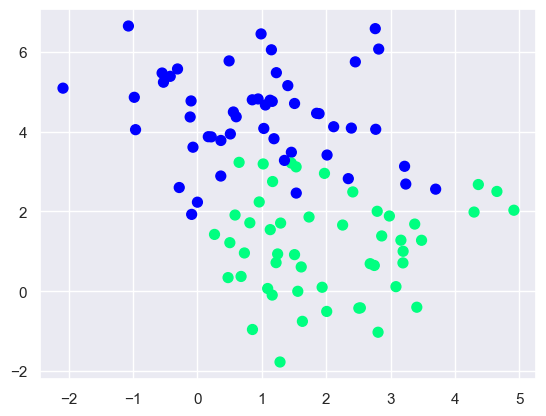

In [36]:
x, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(x[:, 0], x[:, 1], c=y, s=50, cmap='winter');

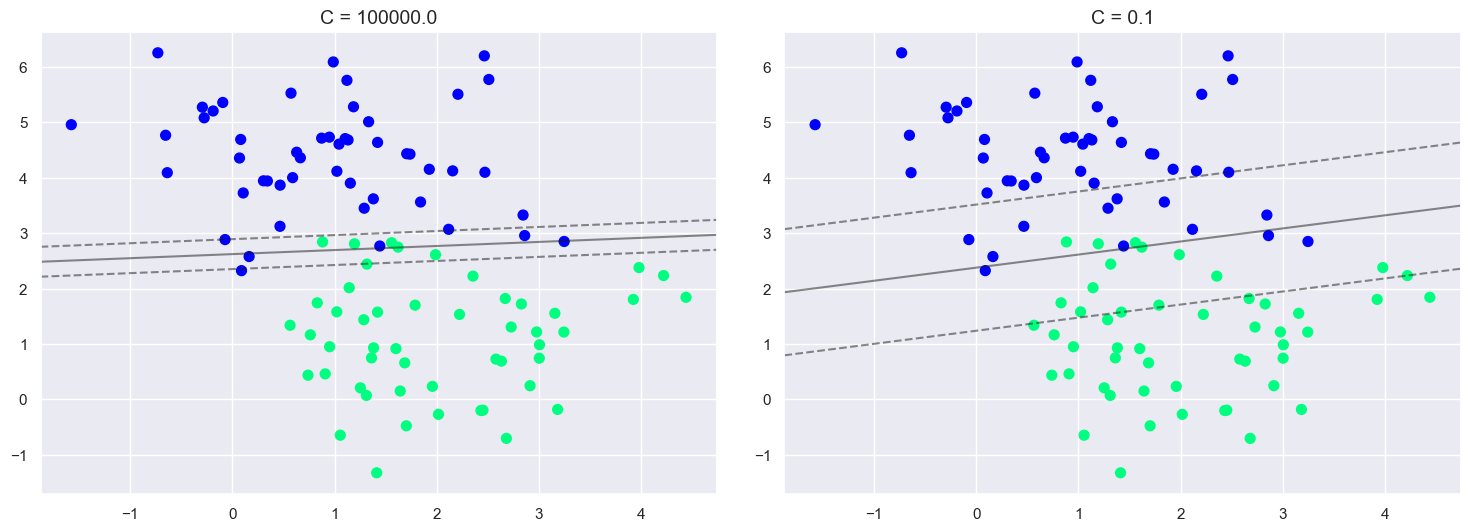

In [38]:
x, y = make_blobs (n_samples=100, centers=2,
                    random_state=0, cluster_std=1)

fig, ax = plt.subplots (1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100000.0, 0.1]):
    model = SVC (kernel='linear', C=C).fit(x, y)
    axi.scatter (x[:, 0], x[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)